# Random Forest Amplitude Baseline Walkthrough

Welcome! This notebook walks you step by step through the dummy baseline implemented. By the end you will understand every moving part of the script and know how to adapt it for your own experiments.


## Notebook Objectives

1. Get familiar with the Beacon sleep staging bundle and the helper utilities that load the data.
2. Recreate the amplitude-based feature engineering routine.
3. Visualise raw EEG alongside sleep stages to build intuition.
4. Train and evaluate the Random Forest classifier with a subject-aware split.
5. Generate a competition-ready submission file and persist the trained artefacts.


## How to Use This Notebook

Run the cells from top to bottom. Each section builds on the previous one and mirrors the flow of the command-line training script. If a cell raises an error about missing data or packages, follow the hint in the error message before rerunning the cell.


In [1]:
pip install numpy pandas scikit-learn joblib matplotlib seaborn scipy

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import json
import os
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.signal import spectrogram
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler



In [3]:
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


## Step 1 — Configure Paths and Hyperparameters

Choose where your data lives and where to store the outputs. Update the paths (or export `CS2025_DATA_ROOT`) if your layout differs from the default project structure.


In [6]:
# Base directory containing the Kaggle bundle and model outputs.
BUNDLE_DIR = Path("C:/Users/agath/Documents/CS/ML/beacon-biosignals-sleep-staging-2025") 
MODEL_DIR = Path("C:/Users/agath/Documents/CS/ML/beacon-biosignals-sleep-staging-2025/working") / 'models'
MODEL_OUT = MODEL_DIR / 'rf_amplitude.joblib'
SUMMARY_OUT = MODEL_OUT.with_suffix('.json')
SUBMISSION_OUT = MODEL_DIR / 'rf_amplitude_submission.csv'

# Random Forest hyperparameters and shared constants.
TEST_SIZE = 0.25
N_ESTIMATORS = 400
MAX_DEPTH = None
RANDOM_STATE = 1234

VALID_LABELS = [0, 1, 2, 3, 4]
SAMPLING_RATE = 100
EPOCH_DURATION_SECONDS = 30
NUM_CHANNELS = 5
SAMPLES_PER_EPOCH = SAMPLING_RATE * EPOCH_DURATION_SECONDS

print(f'Bundle directory: {BUNDLE_DIR.absolute()}')

if not BUNDLE_DIR.exists():
    raise FileNotFoundError(
        f'Kaggle bundle not found at {BUNDLE_DIR}. Update DATA_ROOT or set CS2025_DATA_ROOT before continuing.'
    )


Bundle directory: C:\Users\agath\Documents\CS\ML\beacon-biosignals-sleep-staging-2025


## Step 2 — Data Access Helpers


In [7]:
from typing import Iterator, List, Tuple

SAMPLES_PER_CHANNEL = SAMPLING_RATE * EPOCH_DURATION_SECONDS


def _discover_record_ids(base_dir: Path, split: str) -> List[int]:
    """Return the ordered list of record IDs for a split."""
    manifest_path = base_dir / 'records_manifest.csv'
    if manifest_path.exists():
        manifest = pd.read_csv(manifest_path)
        subset = manifest[manifest['split'] == split]
        return subset['record_id'].astype(int).tolist()

    signal_dir = base_dir / f'signals_{split}'
    record_ids: List[int] = []
    for path in sorted(signal_dir.glob('signal_*.npy')):
        try:
            record_ids.append(int(path.stem.split('_')[-1]))
        except ValueError as exc:
            raise ValueError(f'Unexpected signal filename: {path.name}') from exc
    return record_ids


def _load_signal_array(path: Path) -> np.ndarray:
    """Load and validate a signal array shaped (NUM_CHANNELS, samples)."""
    array = np.load(path).astype(np.float32)
    if array.ndim != 2 or array.shape[0] != NUM_CHANNELS:
        raise ValueError(f'Signal array at {path} has shape {array.shape}, expected ({NUM_CHANNELS}, N_samples).')
    if array.shape[1] % SAMPLES_PER_CHANNEL != 0:
        raise ValueError(
            f'Signal array at {path} has {array.shape[1]} samples, not divisible by {SAMPLES_PER_CHANNEL}.'
        )
    return array


def _load_target_array(path: Path) -> np.ndarray:
    """Load the per-epoch labels (1D, int16)."""
    array = np.load(path).astype(np.int16)
    if array.ndim == 2 and array.shape[0] == NUM_CHANNELS:
        array = array[0]
    if array.ndim != 1:
        raise ValueError(f'Target array at {path} must be 1D, found shape {array.shape}.')
    return array


def iter_signals_and_targets(base_dir: Path, split: str) -> Iterator[Tuple[int, np.ndarray, np.ndarray]]:
    """Yield (record_id, signal_array, target_array) tuples for the chosen split."""
    record_ids = _discover_record_ids(base_dir, split)
    if not record_ids:
        raise FileNotFoundError(f'No records found for split={split} under {base_dir}.')

    signal_dir = base_dir / f'signals_{split}'
    target_dir = base_dir / f'targets_{split}'

    for record_id in record_ids:
        signal_path = signal_dir / f'signal_{record_id}.npy'
        target_path = target_dir / f'target_{record_id}.npy'
        if not signal_path.exists() or not target_path.exists():
            raise FileNotFoundError(f'Missing signal/target pair for record {record_id} in split {split}.')
        signal_array = _load_signal_array(signal_path)
        target_array = _load_target_array(target_path)
        yield record_id, signal_array, target_array

def iter_signals_only(base_dir: Path, split: str) -> Iterator[Tuple[int, np.ndarray]]:
    """Yield (record_id, signal_array) tuples without requiring targets."""
    record_ids = _discover_record_ids(base_dir, split)
    if not record_ids:
        raise FileNotFoundError(f'No records found for split={split} under {base_dir}.')

    signal_dir = base_dir / f'signals_{split}'

    for record_id in record_ids:
        signal_path = signal_dir / f'signal_{record_id}.npy'
        if not signal_path.exists():
            raise FileNotFoundError(f'Missing signal for record {record_id} in split {split}.')
        signal_array = _load_signal_array(signal_path)
        yield record_id, signal_array


## Step 3 — Inspect a Single Record

Before engineering features, take a quick tour of the raw arrays to confirm their shapes and label distribution.


In [8]:
def describe_first_record(bundle_dir: Path, split: str = 'train', preview_epochs: int = 2):
    """Print basic statistics for the first record in the requested split."""
    recordings = list(iter_signals_and_targets(bundle_dir, split))
    record_id, signal_array, target_array = recordings[3]
    print(f'Record ID: {record_id}')
    print(f'Signal shape: {signal_array.shape} (channels, samples)')
    print(f'Target shape: {target_array.shape} (epochs)')
    unique, counts = np.unique(target_array, return_counts=True)
    stage_counts = {int(stage): int(count) for stage, count in zip(unique, counts)}
    print('Stage distribution:', stage_counts)
    preview = signal_array[:, : preview_epochs * SAMPLES_PER_EPOCH]
    print(f'Previewed {preview.shape[1] // SAMPLES_PER_EPOCH} epochs worth of samples per channel.')
    return record_id, signal_array, target_array

example_record_id, example_signal, example_targets = describe_first_record(BUNDLE_DIR, 'train')


Record ID: 3
Signal shape: (5, 2970000) (channels, samples)
Target shape: (990,) (epochs)
Stage distribution: {0: 93, 1: 63, 2: 395, 3: 212, 4: 227}
Previewed 2 epochs worth of samples per channel.


### Sleep Stage Labels and Colours

The mapping below helps keep plots readable. Feel free to customise the colour palette or add channel names that match your sensor configuration.


In [9]:
STAGE_LABELS = {0: 'Wake', 1: 'N1', 2: 'N2', 3: 'N3', 4: 'REM', -1: 'Unknown'}
STAGE_COLORS = {
    0: '#d4b483',  # Wake
    1: '#f7a399',  # N1
    2: '#7fcdbb',  # N2
    3: '#41b6c4',  # N3
    4: '#c51b8a',  # REM
    -1: '#9e9e9e',
}
CHANNEL_NAMES = {idx: f'Channel {idx}' for idx in range(NUM_CHANNELS)}


## Step 3a — Plot Example Epochs by Sleep Stage

Visualise one representative 30-second epoch per sleep stage for a chosen channel. This is a great way to see how the signal amplitude and morphology change across stages.


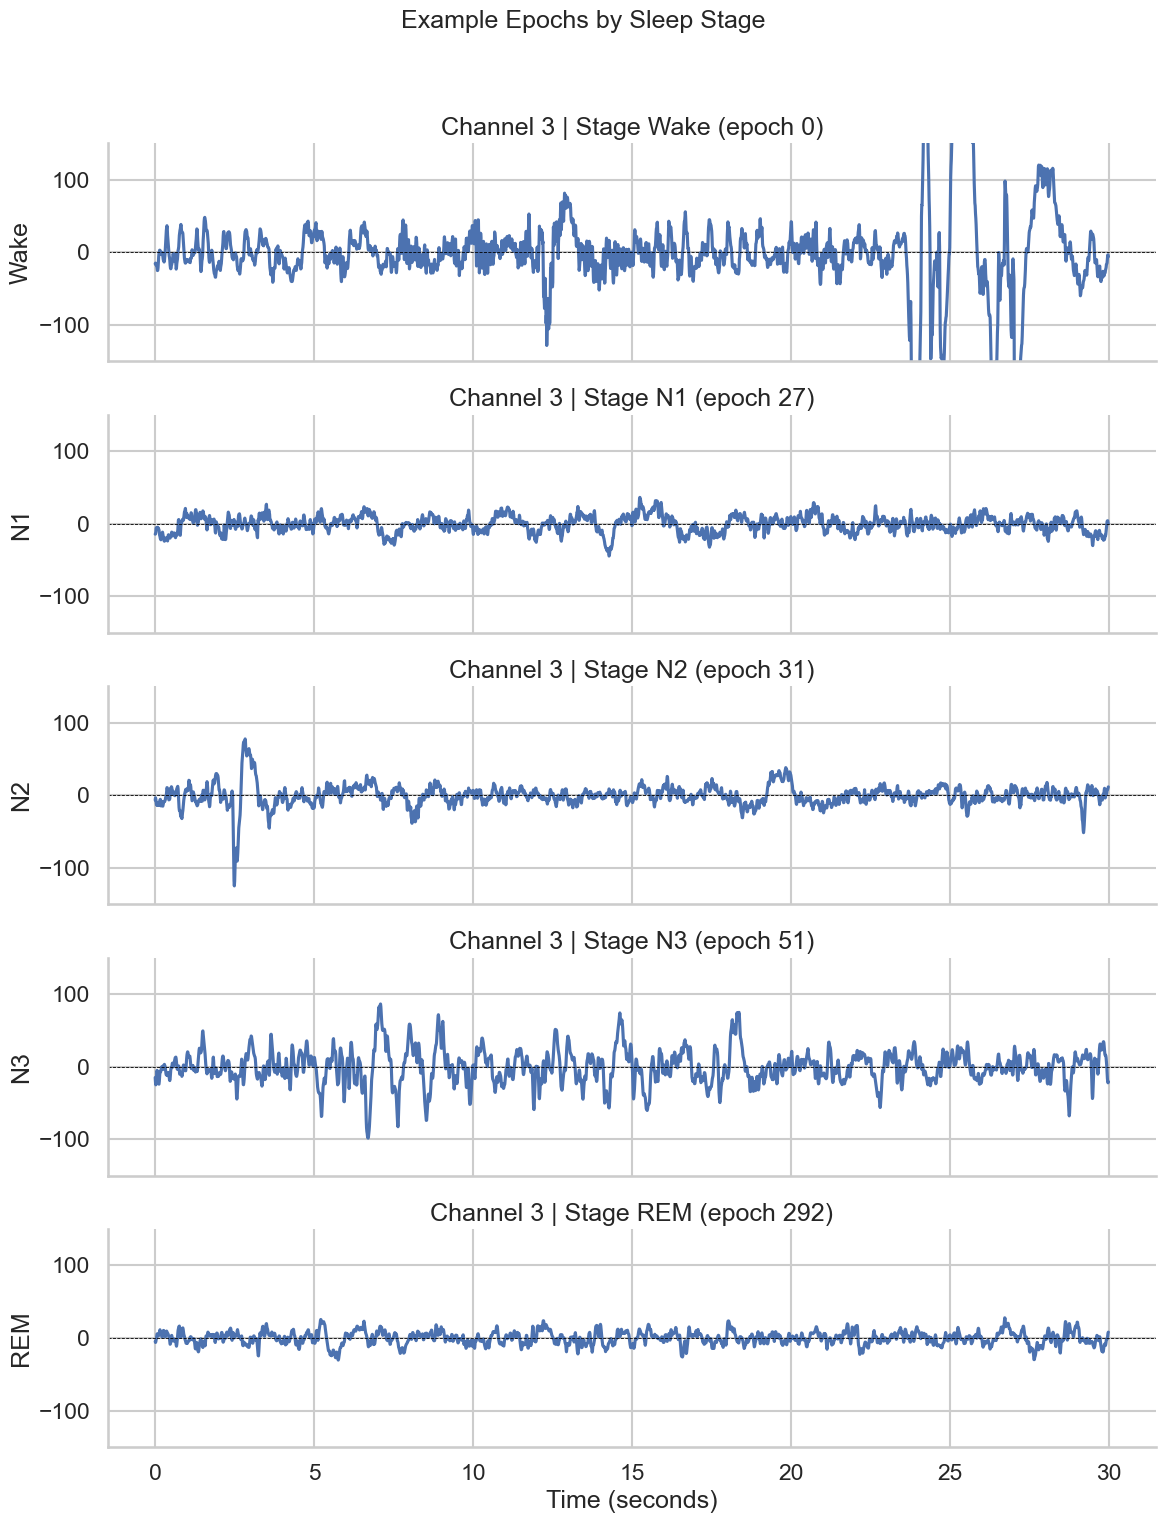

In [10]:
def plot_stage_examples(signal_array: np.ndarray, target_array: np.ndarray, channel: int = 0, stages=None):
    """Plot one example epoch per requested stage for the selected channel."""
    if stages is None:
        stages = VALID_LABELS
    available = []
    for stage in stages:
        matches = np.where(target_array == stage)[0]
        if matches.size:
            available.append((stage, int(matches[0])))
    if not available:
        raise ValueError('None of the requested stages are present in this record.')

    time_axis = np.arange(SAMPLES_PER_EPOCH) / SAMPLING_RATE
    fig, axes = plt.subplots(len(available), 1, figsize=(12, 3 * len(available)), sharex=True)
    if len(available) == 1:
        axes = [axes]

    for ax, (stage, epoch_idx) in zip(axes, available):
        start = epoch_idx * SAMPLES_PER_EPOCH
        epoch_data = signal_array[channel, start : start + SAMPLES_PER_EPOCH]
        ax.plot(time_axis, epoch_data)
        ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
        ax.set_ylim(-150,150)
        ax.set_ylabel(STAGE_LABELS.get(stage, f'Stage {stage}'))
        ax.set_title(f'{CHANNEL_NAMES.get(channel, f"Channel {channel}")} | Stage {STAGE_LABELS.get(stage, stage)} (epoch {epoch_idx})')
    axes[-1].set_xlabel('Time (seconds)')
    fig.suptitle('Example Epochs by Sleep Stage', fontsize=18, y=1.02)
    plt.tight_layout()

plot_stage_examples(example_signal, example_targets, channel=3)


In [53]:
len(example_signal[0])/60

49500.0

## Step 3b — Compare Channels Within a Single Epoch

Pick one epoch (for example the first REM segment) and plot all channels stacked together. This highlights inter-channel differences such as eye movements or muscle tone.


Visualising epoch 292 (Stage REM)


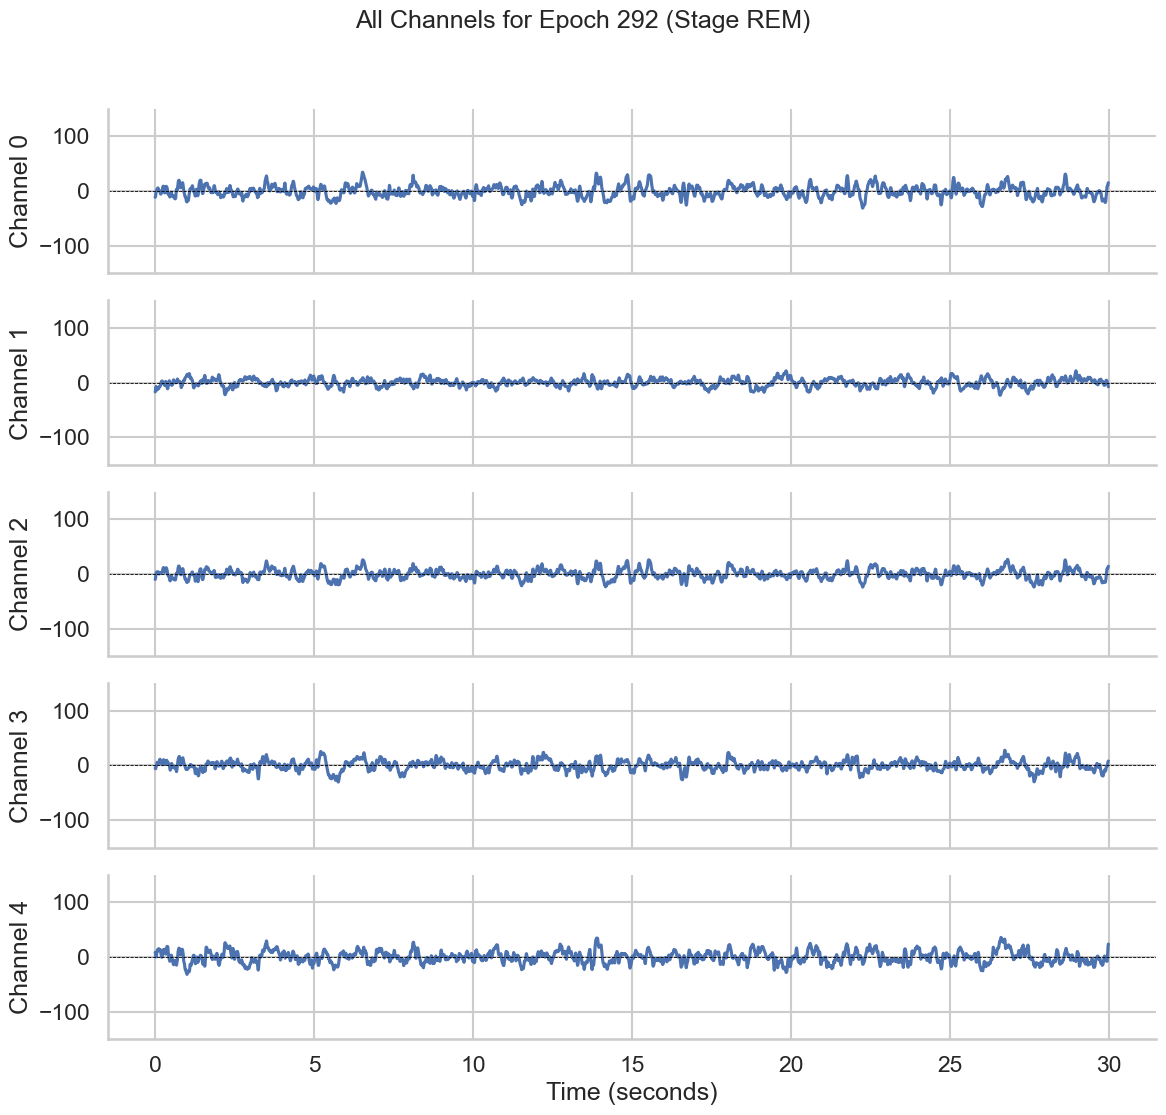

In [11]:
def plot_epoch_across_channels(signal_array: np.ndarray, target_array: np.ndarray, epoch_idx: int):
    """Plot every channel for a single epoch index."""
    if epoch_idx < 0 or epoch_idx >= target_array.size:
        raise IndexError(f'Epoch index {epoch_idx} is out of range for this record.')
    stage = int(target_array[epoch_idx])
    start = epoch_idx * SAMPLES_PER_EPOCH
    time_axis = np.arange(SAMPLES_PER_EPOCH) / SAMPLING_RATE

    fig, axes = plt.subplots(NUM_CHANNELS, 1, figsize=(12, 2.2 * NUM_CHANNELS), sharex=True)
    for ch, ax in enumerate(axes):
        epoch_data = signal_array[ch, start : start + SAMPLES_PER_EPOCH]
        ax.plot(time_axis, epoch_data, color='#4c72b0')
        ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
        ax.set_ylabel(CHANNEL_NAMES.get(ch, f'Ch {ch}'))
        ax.set_ylim(-150,150)

    axes[-1].set_xlabel('Time (seconds)')
    fig.suptitle(
        f'All Channels for Epoch {epoch_idx} (Stage {STAGE_LABELS.get(stage, stage)})',
        fontsize=18,
        y=1.02,
    )
    plt.tight_layout()

# Choose an epoch to visualise — default to the first REM epoch, fall back to epoch 0.
rem_indices = np.where(example_targets == 4)[0]
example_epoch_idx = int(rem_indices[0]) if rem_indices.size else 0
print(f'Visualising epoch {example_epoch_idx} (Stage {STAGE_LABELS.get(int(example_targets[example_epoch_idx]), "?")})')
plot_epoch_across_channels(example_signal, example_targets, example_epoch_idx)


## Step 3c — Spectrogram and Hypnogram Overview

The figure below shows a time-frequency spectrogram for one channel alongside the up-sampled hypnogram. Spectral power concentrates in different bands depending on the sleep stage, which helps explain why even simple statistics can carry signal.

You can find more details on the frequency content of sleep stages here:
https://pmc.ncbi.nlm.nih.gov/articles/PMC5343535/


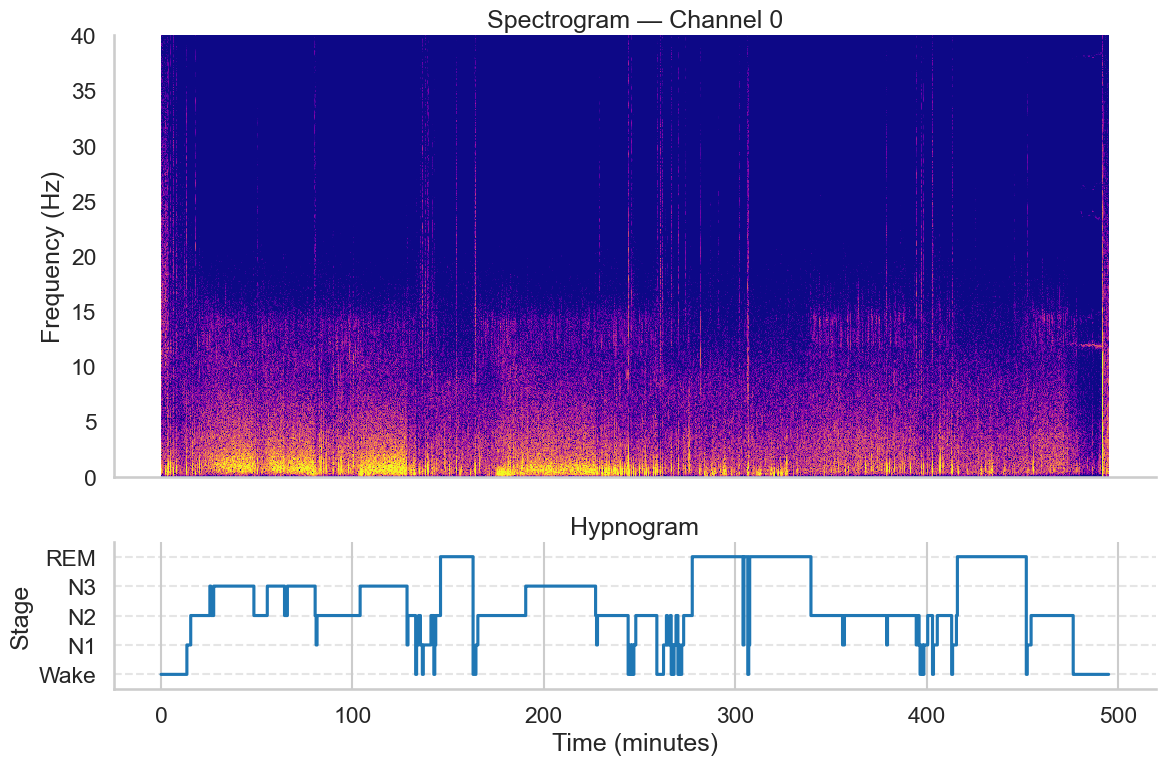

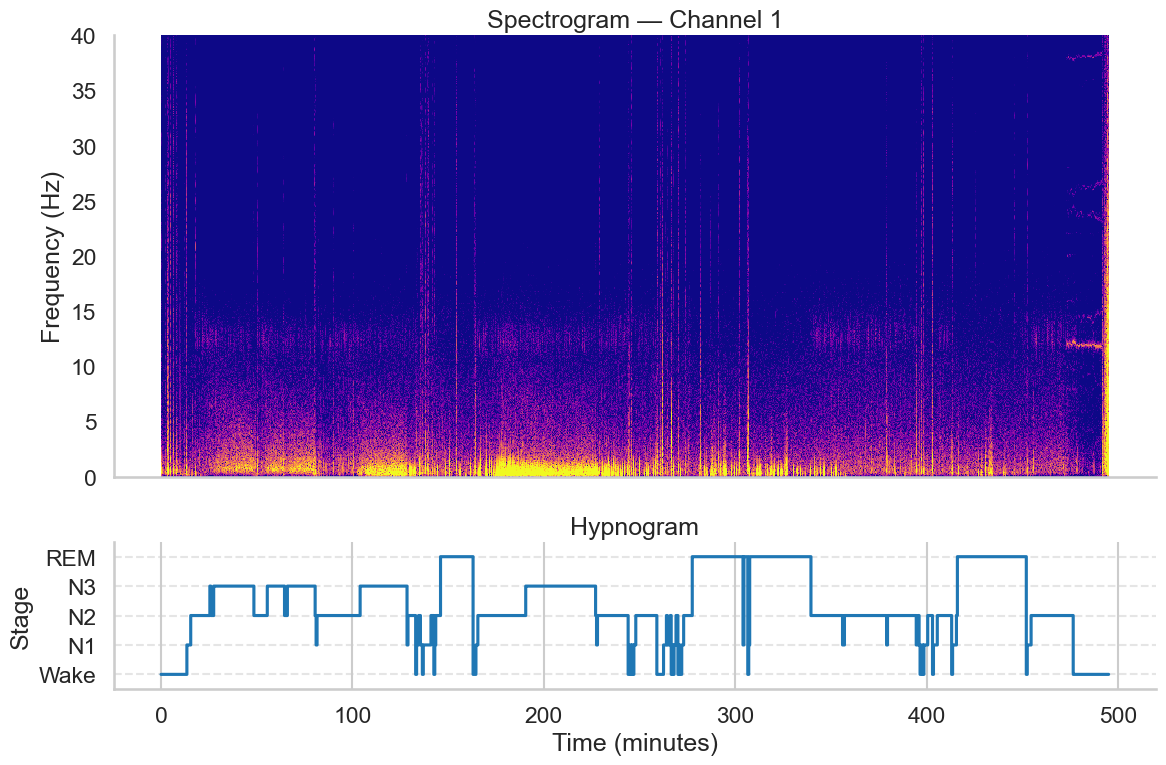

In [12]:
def _upsample_hypnogram(hypno: np.ndarray, samples_per_epoch: int, total_samples: int) -> np.ndarray:
    """Repeat hypnogram epochs so they align with raw sample spacing."""
    repeated = np.repeat(hypno, samples_per_epoch)
    if repeated.size < total_samples:
        pad_value = repeated[-1] if repeated.size else -1
        pad = np.full(total_samples - repeated.size, pad_value, dtype=repeated.dtype)
        repeated = np.concatenate([repeated, pad])
    return repeated[:total_samples]


def _compute_bin_edges(values: np.ndarray) -> np.ndarray:
    """Approximate bin edges from sample centres for pcolormesh."""
    if values.size < 2:
        step = 1.0
    else:
        step = np.diff(values).mean()
    edges = np.concatenate([
        [values[0] - step / 2],
        values[:-1] + step / 2,
        [values[-1] + step / 2],
    ])
    return edges


def plot_spectrogram_and_hypnogram(signal_array: np.ndarray, target_array: np.ndarray, channel: int = 0, max_freq: float = 40.0):
    """Plot a spectrogram with the corresponding hypnogram underneath."""
    data = signal_array[channel]
    freqs_spec, times_spec, spec = spectrogram(
        data,
        fs=SAMPLING_RATE,
        nperseg=SAMPLING_RATE * 10,
        noverlap=SAMPLING_RATE * 5,
        detrend=False,
        scaling="density",
        mode="psd"
    )
    power_db = 10 * np.log10(spec + 1e-12)
    power_db = np.clip(power_db,-5,30)
    hypno_samples = _upsample_hypnogram(target_array, SAMPLES_PER_EPOCH, data.size)
    hypno_time = np.arange(hypno_samples.size) / SAMPLING_RATE / 60

    time_edges = _compute_bin_edges(times_spec / 60)
    freq_edges = _compute_bin_edges(freqs_spec)

    fig, (ax_spec, ax_hypno) = plt.subplots(
        2,
        1,
        figsize=(12, 8),
        sharex=True,
        gridspec_kw={'height_ratios': [3, 1]},
    )

    mesh = ax_spec.pcolormesh(time_edges, freq_edges, power_db, cmap='plasma')
    ax_spec.set_ylabel('Frequency (Hz)')
    ax_spec.set_title(f'Spectrogram — {CHANNEL_NAMES.get(channel, f"Channel {channel}")}')
    ax_spec.set_ylim(0, max_freq)

    ax_hypno.step(hypno_time, hypno_samples, where='post', color='#1f77b4')
    ax_hypno.set_ylabel('Stage')
    ax_hypno.set_xlabel('Time (minutes)')
    ax_hypno.set_yticks(sorted(STAGE_LABELS.keys()))
    ax_hypno.set_yticklabels([STAGE_LABELS[key] for key in sorted(STAGE_LABELS.keys())])
    ax_hypno.set_title('Hypnogram')
    ax_hypno.set_ylim(-0.5, 4.5)
    ax_hypno.grid(True, axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout()

plot_spectrogram_and_hypnogram(example_signal, example_targets, channel=0)
plot_spectrogram_and_hypnogram(example_signal, example_targets, channel=1)


## Step 4 — Feature Engineering Helpers

Each 30-second epoch is summarised by four amplitude-based statistics per channel: standard deviation, minimum, maximum, and peak-to-peak range. These helpers match the functions in the CLI script.


In [110]:
from typing import Dict, List, Tuple


def extract_epoch_stats(signal: np.ndarray) -> pd.DataFrame:
    """Convert a multi-channel signal into one row per epoch of amplitude statistics."""
    num_epochs = signal.shape[1] // SAMPLES_PER_EPOCH
    rows: List[Dict[str, float]] = []
    for epoch_idx in range(num_epochs):
        start = epoch_idx * SAMPLES_PER_EPOCH
        end = start + SAMPLES_PER_EPOCH
        row: Dict[str, float] = {'epoch_index': epoch_idx}
        for ch in range(NUM_CHANNELS):
            channel_signal = signal[ch, start:end]
            row[f'ch{ch}_std'] = float(np.std(channel_signal))
            row[f'ch{ch}_min'] = float(channel_signal.min())
            row[f'ch{ch}_max'] = float(channel_signal.max())
            row[f'ch{ch}_ptp'] = float(np.ptp(channel_signal))  # peak-to-peak range
        rows.append(row)
    return pd.DataFrame(rows)


# ...existing code...
from scipy.signal import welch
# ...existing code...

def _bandpower(signal_1d: np.ndarray, fs: float, band: Tuple[float, float]) -> float:
    """power spectral density in band"""
    freqs, psd = welch(signal_1d, fs=fs, nperseg=min(1024, signal_1d.size), detrend=False)
    idx = (freqs >= band[0]) & (freqs <= band[1])
    return float(np.trapz(psd[idx], freqs[idx])) if idx.any() else 0.0

def _dominant_freq(signal_1d: np.ndarray, fs: float) -> Tuple[float, float, float]:
    """Return (f_min, f_max, f_centroid) of the signal's power spectral density."""
    freqs, psd = welch(signal_1d, fs=fs, nperseg=min(1024, signal_1d.size), detrend=False)
    if psd.size == 0:
        return 0.0, 0.0, 0.0
    dom_f = float(freqs[np.argmax(psd)])
    centroid = float(np.sum(freqs * psd) / np.sum(psd))
    f_min = float(freqs[psd > 0].min()) if np.any(psd > 0) else 0.0
    f_max = float(freqs[psd > 0].max()) if np.any(psd > 0) else 0.0
    return f_min, f_max, dom_f if np.isfinite(centroid) else 0.0

def _petrosian_fd(x: np.ndarray) -> float:
    N = x.size
    if N < 2:
        return 0.0
    diff = np.diff(x)
    N_delta = np.sum(diff[:-1] * diff[1:] < 0)
    return float(np.log10(N) / (np.log10(N) + np.log10(N / (N + 0.4 * N_delta + 1e-12))))

def _katz_fd(x: np.ndarray) -> float:
    N = x.size
    if N < 2:
        return 0.0
    L = np.sum(np.abs(np.diff(x)))
    d = np.max(np.abs(x - x[0])) + 1e-12
    return float(np.log10(N) / (np.log10(d / L + 1e-12) + np.log10(N)))

def _higuchi_fd(x: np.ndarray, k_max: int = 6) -> float:
    N = x.size
    if N < 2:
        return 0.0
    Lk = []
    for k in range(1, k_max + 1):
        Lm = []
        for m in range(k):
            idx = np.arange(m, N, k)
            if idx.size < 2:
                continue
            Lm.append(np.sum(np.abs(np.diff(x[idx]))) * (N - 1) / (k * idx.size))
        if Lm:
            Lk.append(np.mean(Lm))
    if len(Lk) < 2:
        return 0.0
    logk = np.log(np.arange(1, len(Lk) + 1))
    return float(np.polyfit(logk, np.log(Lk), 1)[0]) * -1

def _mmd(x: np.ndarray, fs: int) -> float:
    win = fs  # 1 s windows
    if x.size < win:
        return 0.0
    dist = 0.0
    for start in range(0, x.size - win + 1, win):
        seg = x[start:start + win]
        t_max, t_min = np.argmax(seg), np.argmin(seg)
        a_max, a_min = seg[t_max], seg[t_min]
        dist += np.sqrt((t_max - t_min) ** 2 + (a_max - a_min) ** 2)
    return float(dist)

def _esis(x: np.ndarray, fs: int) -> float:
    # velocity ~ spectral centroid * wavelength (power-of-10 of epoch length)
    freqs, psd = welch(x, fs=fs, nperseg=min(1024, x.size), detrend=False)
    centroid = float(np.sum(freqs * psd) / np.sum(psd)) if psd.size and np.sum(psd) > 0 else 0.0
    wavelength = 10 ** int(np.log10(max(1, x.size)))
    velocity = centroid * wavelength
    return float(np.sum((x ** 2) * velocity))

def _neighbor_corr(sig: np.ndarray, start: int, end: int, fs: int) -> Tuple[float, float]:
    prev_seg = sig[start - fs:end - fs] if start - fs >= 0 else None
    next_seg = sig[start + fs:end + fs] if end + fs <= sig.size else None
    cur = sig[start:end]
    def corr(a, b):
        if a is None or b is None or a.size != b.size:
            return 0.0
        if np.std(a) == 0 or np.std(b) == 0:
            return 0.0
        return float(np.corrcoef(a, b)[0, 1])
    return corr(prev_seg, cur), corr(cur, next_seg)

def extract_epoch_stats2(signal: np.ndarray) -> pd.DataFrame:
    """Convert a multi-channel signal into one row per epoch of rich statistics."""
    num_epochs = signal.shape[1] // SAMPLES_PER_EPOCH
    rows: List[Dict[str, float]] = []
    bands = {
        "wake": (0.5, 2),
        "n1": (4, 7),
        "n2": (11, 16),
        "n3": (0.5, 2),
        "rem": (0.5, 30),
    }
    for epoch_idx in range(num_epochs):
        start = epoch_idx * SAMPLES_PER_EPOCH
        end = start + SAMPLES_PER_EPOCH
        row: Dict[str, float] = {"epoch_index": epoch_idx}
        for ch in range(NUM_CHANNELS):
            x = signal[ch, start:end]

            # Amplitude stats
            row[f"ch{ch}_mean"] = float(np.mean(x))
            row[f"ch{ch}_std"] = float(np.std(x))
            row[f"ch{ch}_min"] = float(x.min())
            row[f"ch{ch}_max"] = float(x.max())
            row[f"ch{ch}_ptp"] = float(np.ptp(x))

            # Frequency stats (Welch)
            fmin, fmax, fcentroid = _dominant_freq(x, SAMPLING_RATE)
            row[f"ch{ch}_fcentroid"] = fcentroid
            row[f"ch{ch}_fdom"] = fmin if fmin == fmax else float(fcentroid)

            # Band powers
            total_power = _bandpower(x, SAMPLING_RATE, (0.5, SAMPLING_RATE / 2))
            for band_name, band in bands.items():
                bp = _bandpower(x, SAMPLING_RATE, band)
                row[f"ch{ch}_bp_{band_name}"] = bp
                row[f"ch{ch}_rbp_{band_name}"] = bp / total_power if total_power > 0 else 0.0
            row[f"ch{ch}_n3_amp_gt75"] = 1.0 if (np.ptp(x) > 75 and _bandpower(x, SAMPLING_RATE, bands["n3"]) > 0) else 0.0 # peak >75microV N3

            # MMD & Esis
            row[f"ch{ch}_mmd"] = _mmd(x, SAMPLING_RATE)
            row[f"ch{ch}_esis"] = _esis(x, SAMPLING_RATE)

            # Fractal dimensions
            row[f"ch{ch}_pfd"] = _petrosian_fd(x)
            row[f"ch{ch}_kfd"] = _katz_fd(x)
            row[f"ch{ch}_hfd"] = _higuchi_fd(x)

            # Neighbor correlations (prev / next epoch)
            prev_corr, next_corr = _neighbor_corr(signal[ch], start, end, SAMPLES_PER_EPOCH) #SAMPLES_PER_EPOCH
            row[f"ch{ch}_corr_prev"] = prev_corr
            row[f"ch{ch}_corr_next"] = next_corr

        rows.append(row)
    return pd.DataFrame(rows)
# ...existing code...


def build_dataset(
    bundle_dir: Path,
    split: str,
    drop_invalid: bool = True,
) -> Tuple[pd.DataFrame, np.ndarray, np.ndarray, pd.DataFrame]:
    """Create the feature table, labels, and per-record group IDs for a split."""
    feature_frames: List[pd.DataFrame] = []
    labels: List[np.ndarray] = []
    groups: List[np.ndarray] = []

    for record_id, signal_array, target_array in iter_signals_and_targets(bundle_dir, split):
        frame = extract_epoch_stats3(signal_array)
        frame['record_id'] = record_id
        feature_frames.append(frame)

        stages = target_array if target_array.ndim == 1 else target_array[0]
        labels.append(stages[: frame.shape[0]])
        groups.append(np.full(frame.shape[0], record_id, dtype=np.int64))

    features = pd.concat(feature_frames, ignore_index=True)
    y = np.concatenate(labels).astype(np.int64)
    groups_arr = np.concatenate(groups).astype(np.int64)
    mask = np.isin(y, VALID_LABELS)

    if drop_invalid:
        features = features.loc[mask].reset_index(drop=True)
        y = y[mask]
        groups_arr = groups_arr[mask]
    meta = features[['record_id', 'epoch_index']].reset_index(drop=True)

    feature_cols = [col for col in features.columns if col not in {'record_id', 'epoch_index'}]
    return features[feature_cols], y, groups_arr, meta


def evaluate(model: RandomForestClassifier, X: np.ndarray, y: np.ndarray) -> Tuple[float, float, str]:
    """Compute accuracy, macro F1, and a detailed classification report."""
    preds = model.predict(X)
    mask = np.isin(y, VALID_LABELS)
    if mask.sum() == 0:
        raise ValueError('No scored epochs available for evaluation.')
    y_masked = y[mask]
    preds_masked = preds[mask]
    acc = accuracy_score(y_masked, preds_masked)
    macro_f1 = f1_score(y_masked, preds_masked, average='macro')
    report = classification_report(y_masked, preds_masked, digits=3)
    return acc, macro_f1, report


In [295]:
# ...existing code...
from itertools import combinations
from scipy.signal import spectrogram
# ...existing code...

def _band_power_series(x: np.ndarray, fs: int, bands: Dict[str, Tuple[float, float]], nperseg: int = 256, noverlap: int = 128) -> Dict[str, np.ndarray]:
    """Return a time series of band power for each band using a spectrogram."""
    freqs, times, Sxx = spectrogram(
        x,
        fs=fs,
        nperseg=min(nperseg, x.size),
        noverlap=min(noverlap, max(0, min(nperseg, x.size) - 1)),
        detrend=False,
        scaling="density",
        mode="psd",
    )
    out = {}
    for name, (f_lo, f_hi) in bands.items():
        mask = (freqs >= f_lo) & (freqs <= f_hi)
        out[name] = Sxx[mask].sum(axis=0) if mask.any() else np.zeros_like(times)
    return out

def _autocorr_1d(x: np.ndarray, max_lag: int) -> np.ndarray:
    """Normalised autocorrelation for lags 1..max_lag."""
    x = x - np.mean(x)
    if x.size < 2:
        return np.zeros(max_lag)
    ac_full = np.correlate(x, x, mode="full")
    mid = ac_full.size // 2
    ac = ac_full[mid: mid + max_lag + 1]
    if ac[0] == 0:
        return np.zeros(max_lag)
    ac = ac / ac[0]
    return ac[1:]  # drop lag 0
# ...existing code...

def _morlet_wavelet(f0: float, fs: float, n_cycles: float = 6.0) -> tuple[np.ndarray, np.ndarray]:
    """Morlet complexe centrée sur f0, normalisée L2."""
    duration = n_cycles / f0
    t = np.arange(-duration / 2, duration / 2, 1.0 / fs)
    sigma_t = n_cycles / (2 * np.pi * f0)
    w = np.exp(2j * np.pi * f0 * t) * np.exp(-t**2 / (2 * sigma_t**2))
    w /= np.sqrt(np.sum(np.abs(w) ** 2))
    return t, w

def _morlet_energies(x: np.ndarray, fs: float) -> dict[float, float]:
    """Énergie moyenne du signal filtré par Morlet à chaque fréquence."""
    freqs_n_cycles = [(0.7,30),(1,3),(1.5,3),(2,3),(3.2,3),(3,5),(4,5),(5,5),(6,5),
                      (8,10),(10,10),(12,10),(12,3),(13,3),(14,3),(15,3),(16,3),(18,3),(20,5),(40,5)]
    energies = {}
    for f,n_c in freqs_n_cycles:
        _, w = _morlet_wavelet(f, fs, n_cycles=n_c)
        conv = np.convolve(x, w, mode="same")
        energies[f,n_c] = float(np.mean(np.abs(conv) ** 2))
    return energies

def extract_epoch_stats3(signal: np.ndarray) -> pd.DataFrame:
    """Convert a multi-channel signal into one row per epoch of rich statistics."""
    num_epochs = signal.shape[1] // SAMPLES_PER_EPOCH
    rows: List[Dict[str, float]] = []
    bands = {
        "wake": (0.5, 2),
        "n1": (4, 7),
        "n2": (11, 16),
        "n3": (0.5, 2),
        "rem": (0.5, 30),
    }
    for epoch_idx in range(num_epochs):
        start = epoch_idx * SAMPLES_PER_EPOCH
        end = start + SAMPLES_PER_EPOCH
        row: Dict[str, float] = {"epoch_index": epoch_idx}
        for ch in range(NUM_CHANNELS):
            x = signal[ch, start:end]

            # Amplitude stats
            # row[f"ch{ch}_mean"] = float(np.mean(x))
            row[f"ch{ch}_std"] = float(np.std(x))
            row[f"ch{ch}_min"] = float(x.min())
            row[f"ch{ch}_max"] = float(x.max())
            row[f"ch{ch}_ptp"] = float(np.ptp(x))

            # Time-domain power
            row[f"ch{ch}_time_power"] = float(np.mean(x ** 2))

            # Frequency stats (Welch)
            fmin, fmax, fcentroid = _dominant_freq(x, SAMPLING_RATE)
            row[f"ch{ch}_fcentroid"] = fcentroid
            row[f"ch{ch}_fdom"] = fmin if fmin == fmax else float(fcentroid)

            # Band powers (scalar per epoch)
            total_power = _bandpower(x, SAMPLING_RATE, (0.5, SAMPLING_RATE / 2))
            for band_name, band in bands.items():
                bp = _bandpower(x, SAMPLING_RATE, band)
                # row[f"ch{ch}_bp_{band_name}"] = bp
                row[f"ch{ch}_rbp_{band_name}"] = bp / total_power if total_power > 0 else 0.0
            # row[f"ch{ch}_n3_amp_gt75"] = 1.0 if (np.ptp(x) > 75 and _bandpower(x, SAMPLING_RATE, bands["n3"]) > 0) else 0.0  # peak >75microV N3
            
            # Morlet wavelet energies (fréquences centrales en Hz)
            mw_energy = _morlet_energies(x, SAMPLING_RATE)
            for (f0, n_c), e in mw_energy.items():
                row[f"ch{ch}_mw_energy_{int(f0)}hz_{int(n_c)}cycles"] = e
            # Band-power time series + its power + cross-band correlations
            band_ts = _band_power_series(x, SAMPLING_RATE, bands)
            for bname, series in band_ts.items():
                row[f"ch{ch}_bp_series_power_{bname}"] = float(np.mean(series ** 2))
            # for b1, b2 in combinations(bands.keys(), 2):
            #     s1, s2 = band_ts[b1], band_ts[b2]
            #     if s1.size == 0 or s2.size == 0 or np.std(s1) == 0 or np.std(s2) == 0:
            #         corr = 0.0
            #     else:
            #         corr = float(np.corrcoef(s1, s2)[0, 1])
            #     row[f"ch{ch}_bp_corr_{b1}_{b2}"] = corr

            # MMD & Esis
            row[f"ch{ch}_mmd"] = _mmd(x, SAMPLING_RATE)
            # row[f"ch{ch}_esis"] = _esis(x, SAMPLING_RATE)

            # Fractal dimensions
            # row[f"ch{ch}_pfd"] = _petrosian_fd(x)
            # row[f"ch{ch}_kfd"] = _katz_fd(x)
            row[f"ch{ch}_hfd"] = _higuchi_fd(x)

            # # Neighbor correlations (prev / next epoch)
            # prev_corr, next_corr = _neighbor_corr(signal[ch], start, end, SAMPLES_PER_EPOCH)
            # row[f"ch{ch}_corr_prev"] = prev_corr
            # row[f"ch{ch}_corr_next"] = next_corr

            # Autocorrelation (lags 1..50, i.e., up to 0.5 s at 100 Hz)
            ac = _autocorr_1d(x, max_lag=50)
            for lag, val in enumerate(ac, start=1):
                row[f"ch{ch}_ac_lag{lag}"] = float(val)

        rows.append(row)
    return pd.DataFrame(rows)
# ...existing code...

## Step 5 — Assemble the Training Table

Load every training record, compute the amplitude features, and keep a group ID per record so that we can later split by subject.


In [296]:
X_df, y, groups, train_meta = build_dataset(BUNDLE_DIR, 'train', drop_invalid=True)
print(f'Feature matrix shape: {X_df.shape}')
print(f'Number of labels (epochs): {y.shape[0]}')
print(f'Unique records (groups): {np.unique(groups).size}')
unique_labels, counts = np.unique(y, return_counts=True)
label_counts = dict(zip(unique_labels.astype(int), counts.astype(int)))
print('Label distribution:', label_counts)


Feature matrix shape: (7433, 440)
Number of labels (epochs): 7433
Unique records (groups): 8
Label distribution: {0: 1200, 1: 509, 2: 3269, 3: 1034, 4: 1421}


## Step 6 — Preview the Engineered Features

Each row corresponds to one 30-second epoch. The columns follow the pattern `ch<channel>_<statistic>`.


In [90]:
X_df.head()


,ch0_std,ch0_min,ch0_max,ch0_ptp,ch1_std,ch1_min,ch1_max,ch1_ptp,ch2_std,ch2_min,ch2_max,ch2_ptp,ch3_std,ch3_min,ch3_max,ch3_ptp,ch4_std,ch4_min,ch4_max,ch4_ptp
0,14.748470,-48.057274,50.724537,98.781815,9.868649,-34.139107,28.031101,62.170208,14.940137,-49.766178,52.279408,102.045586,19.156635,-67.986938,84.604477,152.591415,15.657406,-49.656414,53.023392,102.679810
1,13.479313,-47.664841,44.938030,92.602875,10.761889,-33.379131,38.473232,71.852364,13.365528,-44.376301,47.617195,91.993500,16.705683,-57.334995,63.577480,120.912476,15.209505,-61.318268,54.494770,115.813034
2,12.754451,-40.995800,38.321629,79.317429,12.616886,-35.074650,36.007763,71.082413,12.786792,-37.265766,38.607204,75.872971,15.894444,-45.378029,68.583969,113.961998,15.382261,-48.180893,62.903275,111.084167
3,12.342356,-36.973747,48.952374,85.926117,10.898625,-33.208801,33.620014,66.828812,11.644698,-37.523716,46.018715,83.542435,15.332358,-43.931164,65.512947,109.444107,13.394090,-49.262760,45.204140,94.466904
4,12.303305,-38.078606,55.881653,93.960258,11.492809,-34.299324,31.219952,65.519272,11.919007,-37.271744,58.120087,95.391830,14.578304,-67.635323,59.162266,126.797592,13.015830,-49.806198,39.853085,89.659286


## Step 7 — Standardise the Features

Scaling keeps the Random Forest from being dominated by features with large numeric ranges.


In [297]:
scaler = StandardScaler()
X = scaler.fit_transform(X_df)
print(f'Scaled matrix shape: {X.shape}')


Scaled matrix shape: (7433, 440)


In [271]:
X_df.head()

,ch0_std,ch0_min,ch0_max,ch0_ptp,ch0_time_power,ch0_fcentroid,ch0_fdom,ch0_bp_wake,ch0_rbp_wake,ch0_bp_n1,...,ch4_ac_lag41,ch4_ac_lag42,ch4_ac_lag43,ch4_ac_lag44,ch4_ac_lag45,ch4_ac_lag46,ch4_ac_lag47,ch4_ac_lag48,ch4_ac_lag49,ch4_ac_lag50
0,14.748470,-48.057274,50.724537,98.781815,217.519882,9.375000,9.375000,16.705007,0.074832,7.134447,...,-0.006197,0.037517,0.056910,0.042660,0.007956,-0.044676,-0.097253,-0.130152,-0.141389,-0.124285
1,13.479313,-47.664841,44.938030,92.602875,181.692795,10.937500,10.937500,13.646881,0.079283,7.114794,...,-0.019524,0.004739,0.018815,0.008220,-0.019294,-0.061325,-0.099747,-0.120701,-0.128387,-0.116757
2,12.754451,-40.995800,38.321629,79.317429,162.676071,10.937500,10.937500,13.246075,0.082163,7.353584,...,0.149201,0.154737,0.146787,0.123138,0.099178,0.075705,0.061900,0.059068,0.054621,0.058132
3,12.342356,-36.973747,48.952374,85.926117,152.336014,10.644531,10.644531,11.307591,0.075564,5.952028,...,0.112486,0.106407,0.097857,0.082193,0.075990,0.069720,0.064400,0.059075,0.042400,0.034660
4,12.303305,-38.078606,55.881653,93.960258,151.378021,11.132812,11.132812,17.527790,0.122663,7.658816,...,0.118068,0.107516,0.100094,0.085697,0.074942,0.055594,0.033384,0.016152,0.000589,0.008907


In [307]:
# Use numpy array indexing to select the kept feature names
len(np.asarray(X_df.columns)[kept_features])

139

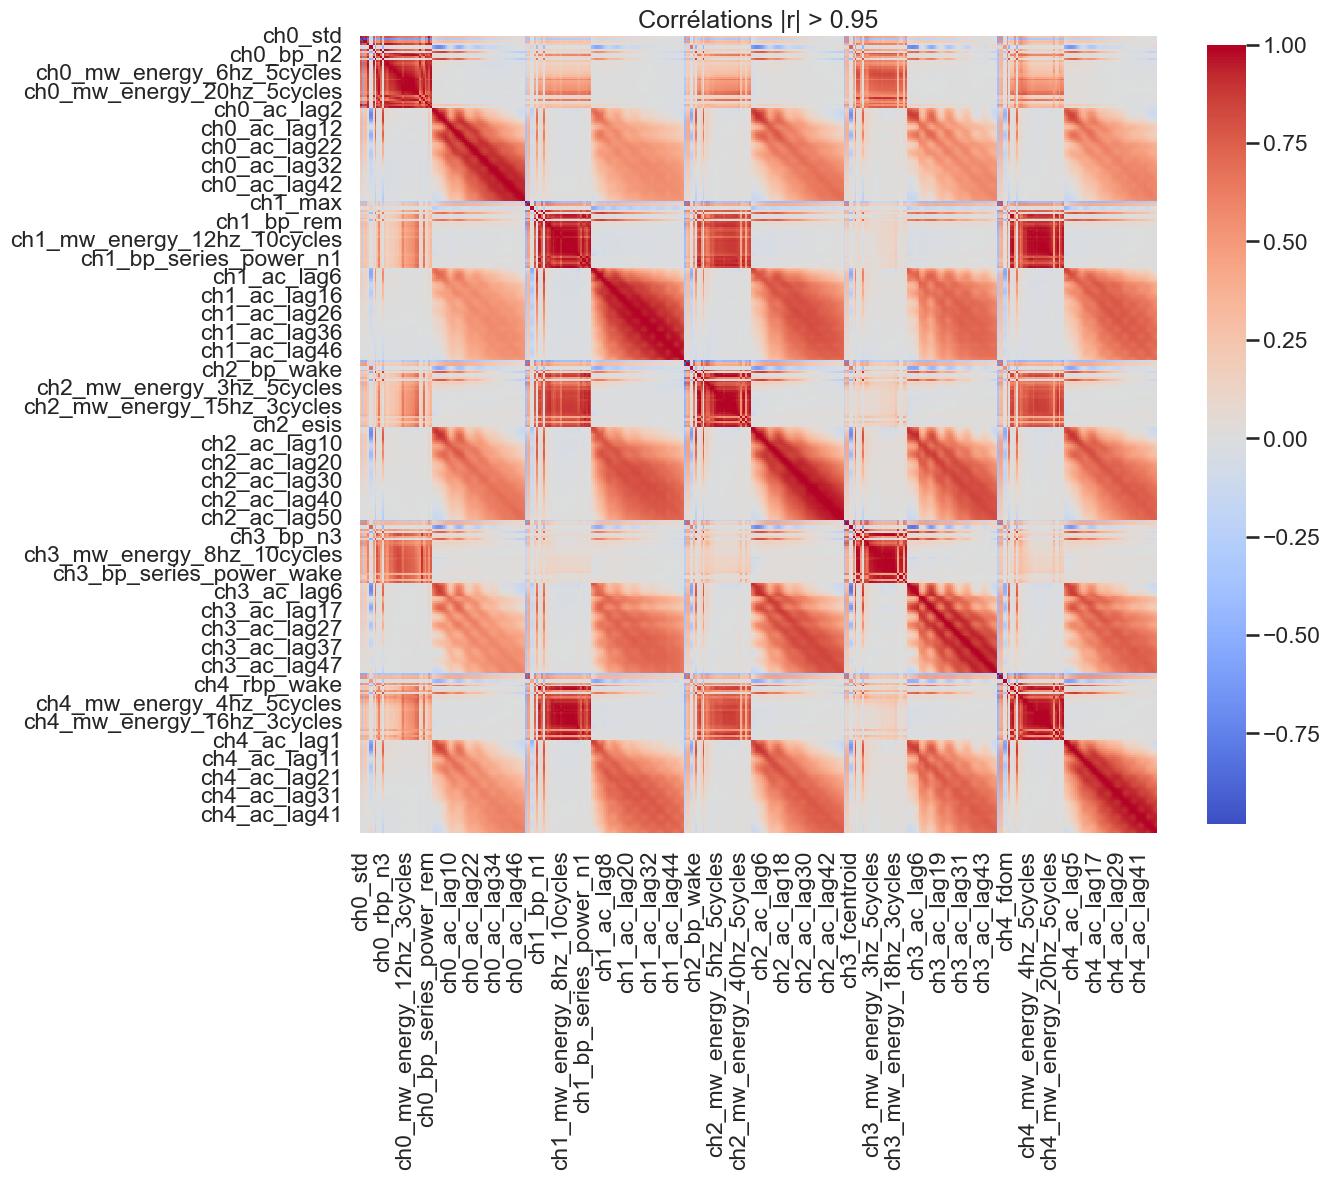

In [ ]:
# ...existing code...
# Corrélations fortes uniquement (|r| > 0.95)
X_df = pd.DataFrame(X_df, columns=X_df.columns)
corr = X_df.corr()
thr = 0.95
mask_upper = np.triu(np.ones_like(corr, dtype=bool), k=1)
strong_pairs = (corr.where(mask_upper).abs() > thr)

cols_strong = strong_pairs.any(axis=0)
rows_strong = strong_pairs.any(axis=1)
keep_cols = corr.columns[cols_strong | rows_strong]

if len(keep_cols) == 0:
    print(f"Aucune corrélation absolue > {thr}")
else:
    corr_strong = corr.loc[keep_cols, keep_cols]
    plt.figure(figsize=(min(14, 2 + 0.3 * len(keep_cols)), min(14, 2 + 0.3 * len(keep_cols))))
    sns.heatmap(corr_strong, cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": 0.7})
    plt.title(f"Corrélations |r| > {thr}")
    plt.tight_layout()
# ...existing code...

In [249]:
len(high_corr_features)

5

In [294]:
high_corr_features = set()
for feature in corr_strong.abs().columns:
    correlated = corr_strong.index[(corr_strong[feature] > thr) & (corr_strong[feature] < 1.0)].tolist()
    if len(correlated) > 0:
        print(f"Features fortement corrélées avec {feature}: {correlated}")
        high_corr_features.add(feature)

Features fortement corrélées avec ch0_std: ['ch0_mmd']
Features fortement corrélées avec ch0_max: ['ch0_ptp']
Features fortement corrélées avec ch0_ptp: ['ch0_max']
Features fortement corrélées avec ch0_time_power: ['ch0_bp_rem', 'ch0_mw_energy_1hz_3cycles', 'ch0_mw_energy_2hz_3cycles', 'ch0_mw_energy_3hz_3cycles', 'ch0_mw_energy_3hz_5cycles']
Features fortement corrélées avec ch0_bp_wake: ['ch0_bp_rem', 'ch0_mw_energy_1hz_3cycles']
Features fortement corrélées avec ch0_bp_n1: ['ch0_mw_energy_4hz_5cycles', 'ch0_mw_energy_5hz_5cycles']
Features fortement corrélées avec ch0_bp_n2: ['ch0_mw_energy_12hz_10cycles', 'ch0_mw_energy_12hz_3cycles', 'ch0_mw_energy_13hz_3cycles', 'ch0_mw_energy_14hz_3cycles', 'ch0_mw_energy_15hz_3cycles', 'ch0_mw_energy_16hz_3cycles', 'ch0_mw_energy_18hz_3cycles', 'ch0_mw_energy_20hz_5cycles', 'ch0_mw_energy_40hz_5cycles']
Features fortement corrélées avec ch0_bp_n3: ['ch0_bp_rem', 'ch0_mw_energy_1hz_3cycles']
Features fortement corrélées avec ch0_bp_rem: ['ch0_t

In [252]:
len(high_corr_features)

77

In [280]:
X_df.head()

,ch0_std,ch0_min,ch0_max,ch0_ptp,ch0_time_power,ch0_fcentroid,ch0_fdom,ch0_bp_wake,ch0_rbp_wake,ch0_bp_n1,...,ch4_ac_lag41,ch4_ac_lag42,ch4_ac_lag43,ch4_ac_lag44,ch4_ac_lag45,ch4_ac_lag46,ch4_ac_lag47,ch4_ac_lag48,ch4_ac_lag49,ch4_ac_lag50
0,14.748470,-48.057274,50.724537,98.781815,217.519882,9.375000,9.375000,16.705007,0.074832,7.134447,...,-0.006197,0.037517,0.056910,0.042660,0.007956,-0.044676,-0.097253,-0.130152,-0.141389,-0.124285
1,13.479313,-47.664841,44.938030,92.602875,181.692795,10.937500,10.937500,13.646881,0.079283,7.114794,...,-0.019524,0.004739,0.018815,0.008220,-0.019294,-0.061325,-0.099747,-0.120701,-0.128387,-0.116757
2,12.754451,-40.995800,38.321629,79.317429,162.676071,10.937500,10.937500,13.246075,0.082163,7.353584,...,0.149201,0.154737,0.146787,0.123138,0.099178,0.075705,0.061900,0.059068,0.054621,0.058132
3,12.342356,-36.973747,48.952374,85.926117,152.336014,10.644531,10.644531,11.307591,0.075564,5.952028,...,0.112486,0.106407,0.097857,0.082193,0.075990,0.069720,0.064400,0.059075,0.042400,0.034660
4,12.303305,-38.078606,55.881653,93.960258,151.378021,11.132812,11.132812,17.527790,0.122663,7.658816,...,0.118068,0.107516,0.100094,0.085697,0.074942,0.055594,0.033384,0.016152,0.000589,0.008907


## Step 8 — Create a Group-Aware Train/Validation Split

Subjects should not appear on both sides of the split, so we use `GroupShuffleSplit` with record IDs as groups.


In [303]:
X = X[:, kept_features]
X = scaler.fit_transform(X)
print(f'Scaled matrix shape: {X.shape}')
splitter = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx, val_idx = next(splitter.split(X, y, groups))
X_train, X_val = X[train_idx], X[val_idx]
y_train, y_val = y[train_idx], y[val_idx]
print(f'Train epochs: {X_train.shape[0]} | Validation epochs: {X_val.shape[0]}')


Scaled matrix shape: (7433, 139)
Train epochs: 5802 | Validation epochs: 1631


## Step 9 — Train the Random Forest Classifier

This is the exact configuration used by the baseline script.


In [212]:
np.unique(groups[train_idx])

array([0, 3, 4, 5, 6, 7], dtype=int64)

In [209]:
train_idx

array([   0,    1,    2, ..., 7430, 7431, 7432], dtype=int64)

In [ ]:
# cross-validation with GroupKFold to tune n_estimators, max_dephth, min_samples_leaf
from sklearn.model_selection import GroupKFold, cross_val_score

group_ids = groups[train_idx]
_, group_ids_enc = np.unique(group_ids, return_inverse=True)
n_splits = min(3, group_ids_enc.max() + 1)  # at least 1 group per fold
cv = GroupKFold(n_splits=n_splits)
cv_results = []

for n in [10,15,25,20,30]:
    rf = RandomForestClassifier(
        n_estimators=150,
        max_depth=14,
        n_jobs=1,              # avoid nested parallelism with cross_val_score
        class_weight="balanced",
        random_state=RANDOM_STATE,
        min_samples_leaf=10,
    )
    scores = cross_val_score(
        rf, X_train, y_train, groups=group_ids_enc, cv=cv, scoring="f1_macro", n_jobs=-1
    )
    cv_results.append((n, scores.mean(), scores.std()))
    print(f"n_estimators={n}: macro F1 CV mean={scores.mean():.4f} ± {scores.std():.4f}")

best_n, best_mean, best_std = max(cv_results, key=lambda t: t[1])
print(f"\nBest n_estimators={best_n} (macro F1={best_mean:.4f} ± {best_std:.4f})")
N_ESTIMATORS = best_n
# ...existing code...

n_estimators=10: macro F1 CV mean=0.6778 ± 0.0447
n_estimators=15: macro F1 CV mean=0.6663 ± 0.0470
n_estimators=25: macro F1 CV mean=0.6660 ± 0.0427
n_estimators=20: macro F1 CV mean=0.6704 ± 0.0488
n_estimators=30: macro F1 CV mean=0.6629 ± 0.0422

Best n_estimators=10 (macro F1=0.6778 ± 0.0447)


In [316]:
model = RandomForestClassifier(
    n_estimators=150,
    max_depth=14,
    n_jobs=-1,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    min_samples_leaf=10,
    # max_features=0.9,
)
model.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', max_depth=14,
                       min_samples_leaf=10, n_estimators=150, n_jobs=-1,
                       random_state=1234)

## Step 10 — Evaluate on the Validation Split

Accuracy is easy to read, while macro F1 tells us how well the model balances rare stages.


In [290]:
X_train.shape

(5802, 140)

In [317]:
train_acc, train_macro_f1, train_report = evaluate(model, X_train, y_train)
val_acc, val_macro_f1, val_report = evaluate(model, X_val, y_val)

print(f"Train accuracy: {train_acc:.4f} | Train macro F1: {train_macro_f1:.4f}")
print(f"Val   accuracy: {val_acc:.4f} | Val   macro F1: {val_macro_f1:.4f}")

print("\n=== Train report ===")
print(train_report)
print("\n=== Val report ===")
print(val_report)

Train accuracy: 0.9254 | Train macro F1: 0.9065
Val   accuracy: 0.7866 | Val   macro F1: 0.6930

=== Train report ===
              precision    recall  f1-score   support

           0      0.892     0.962     0.925       735
           1      0.693     0.891     0.780       433
           2      0.985     0.904     0.942      2673
           3      0.927     0.986     0.955       761
           4      0.934     0.925     0.929      1200

    accuracy                          0.925      5802
   macro avg      0.886     0.934     0.906      5802
weighted avg      0.933     0.925     0.927      5802


=== Val report ===
              precision    recall  f1-score   support

           0      0.886     0.819     0.851       465
           1      0.225     0.447     0.300        76
           2      0.780     0.893     0.833       596
           3      0.941     0.883     0.911       273
           4      0.848     0.430     0.571       221

    accuracy                          0.787    

In [ ]:
def plot_feature_importance(model: RandomForestClassifier, feature_names: List[str], top_n: int = 20):
    """Plot the top N most important features from a trained Random Forest model."""
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1][:top_n]
    
    fig, ax = plt.subplots(figsize=(10, 30))
    top_importances = importances[indices]
    top_names = [feature_names[i] for i in indices]
    
    bars = ax.barh(range(len(top_names)), top_importances, color='#4c72b0')
    ax.set_yticks(range(len(top_names)))
    ax.set_yticklabels(top_names)
    ax.set_xlabel('Importance')
    ax.set_title(f'Top {top_n} Feature Importances (Random Forest)')
    ax.invert_yaxis()
    
    # Add value labels on bars
    for i, (bar, val) in enumerate(zip(bars, top_importances)):
        ax.text(val, i, f' {val:.4f}', va='center', fontsize=9)
    
    plt.tight_layout()
    return fig, indices, top_importances


def get_feature_importance_df(model: RandomForestClassifier, feature_names: List[str]) -> pd.DataFrame:
    """Return a DataFrame with all features ranked by importance."""
    importances = model.feature_importances_
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False).reset_index(drop=True)
    importance_df['rank'] = importance_df.index + 1
    return importance_df

# Usage:
# importance_df = get_feature_importance_df(model, X_df.columns.tolist())
# print(importance_df.head(30))
# importance_df.to_csv('feature_importance.csv', index=False)

def analyze_feature_by_channel(importance_df: pd.DataFrame) -> pd.DataFrame:
    """Group feature importances by channel to see which channels are most informative."""
    importance_df['channel'] = importance_df['feature'].str.extract(r'(ch\d+)')[0]
    channel_importance = importance_df.groupby('channel')['importance'].agg(['sum', 'mean', 'count']).reset_index()
    channel_importance = channel_importance.sort_values('sum', ascending=False)
    return channel_importance

# Usage:
# channel_importance = analyze_feature_by_channel(importance_df)
# print(channel_importance)
# 
# fig, ax = plt.subplots(figsize=(10, 5))
# ax.bar(channel_importance['channel'], channel_importance['sum'], color='#7fcdbb')
# ax.set_xlabel('Channel')
# ax.set_ylabel('Total Importance')
# ax.set_title('Feature Importance by Channel')
# plt.tight_layout()

def analyze_feature_by_type(importance_df: pd.DataFrame) -> pd.DataFrame:
    """Group feature importances by feature type (std, ptp, bp_*, pfd, etc.)."""
    # Extract feature type (last part after final underscore)
    importance_df['type'] = importance_df['feature'].str.extract(r'_([\w]+)$')[0]
    type_importance = importance_df.groupby('type')['importance'].agg(['sum', 'mean', 'count']).reset_index()
    type_importance = type_importance.sort_values('sum', ascending=False)
    return type_importance

# Usage:
# type_importance = analyze_feature_by_type(importance_df)
# print(type_importance)
# 
# fig, ax = plt.subplots(figsize=(12, 6))
# ax.barh(type_importance['type'], type_importance['sum'], color='#f7a399')
# ax.set_xlabel('Total Importance')
# ax.set_title('Feature Importance by Type (Amplitude, Frequency, Fractal Dim, etc.)')
# plt.tight_layout()

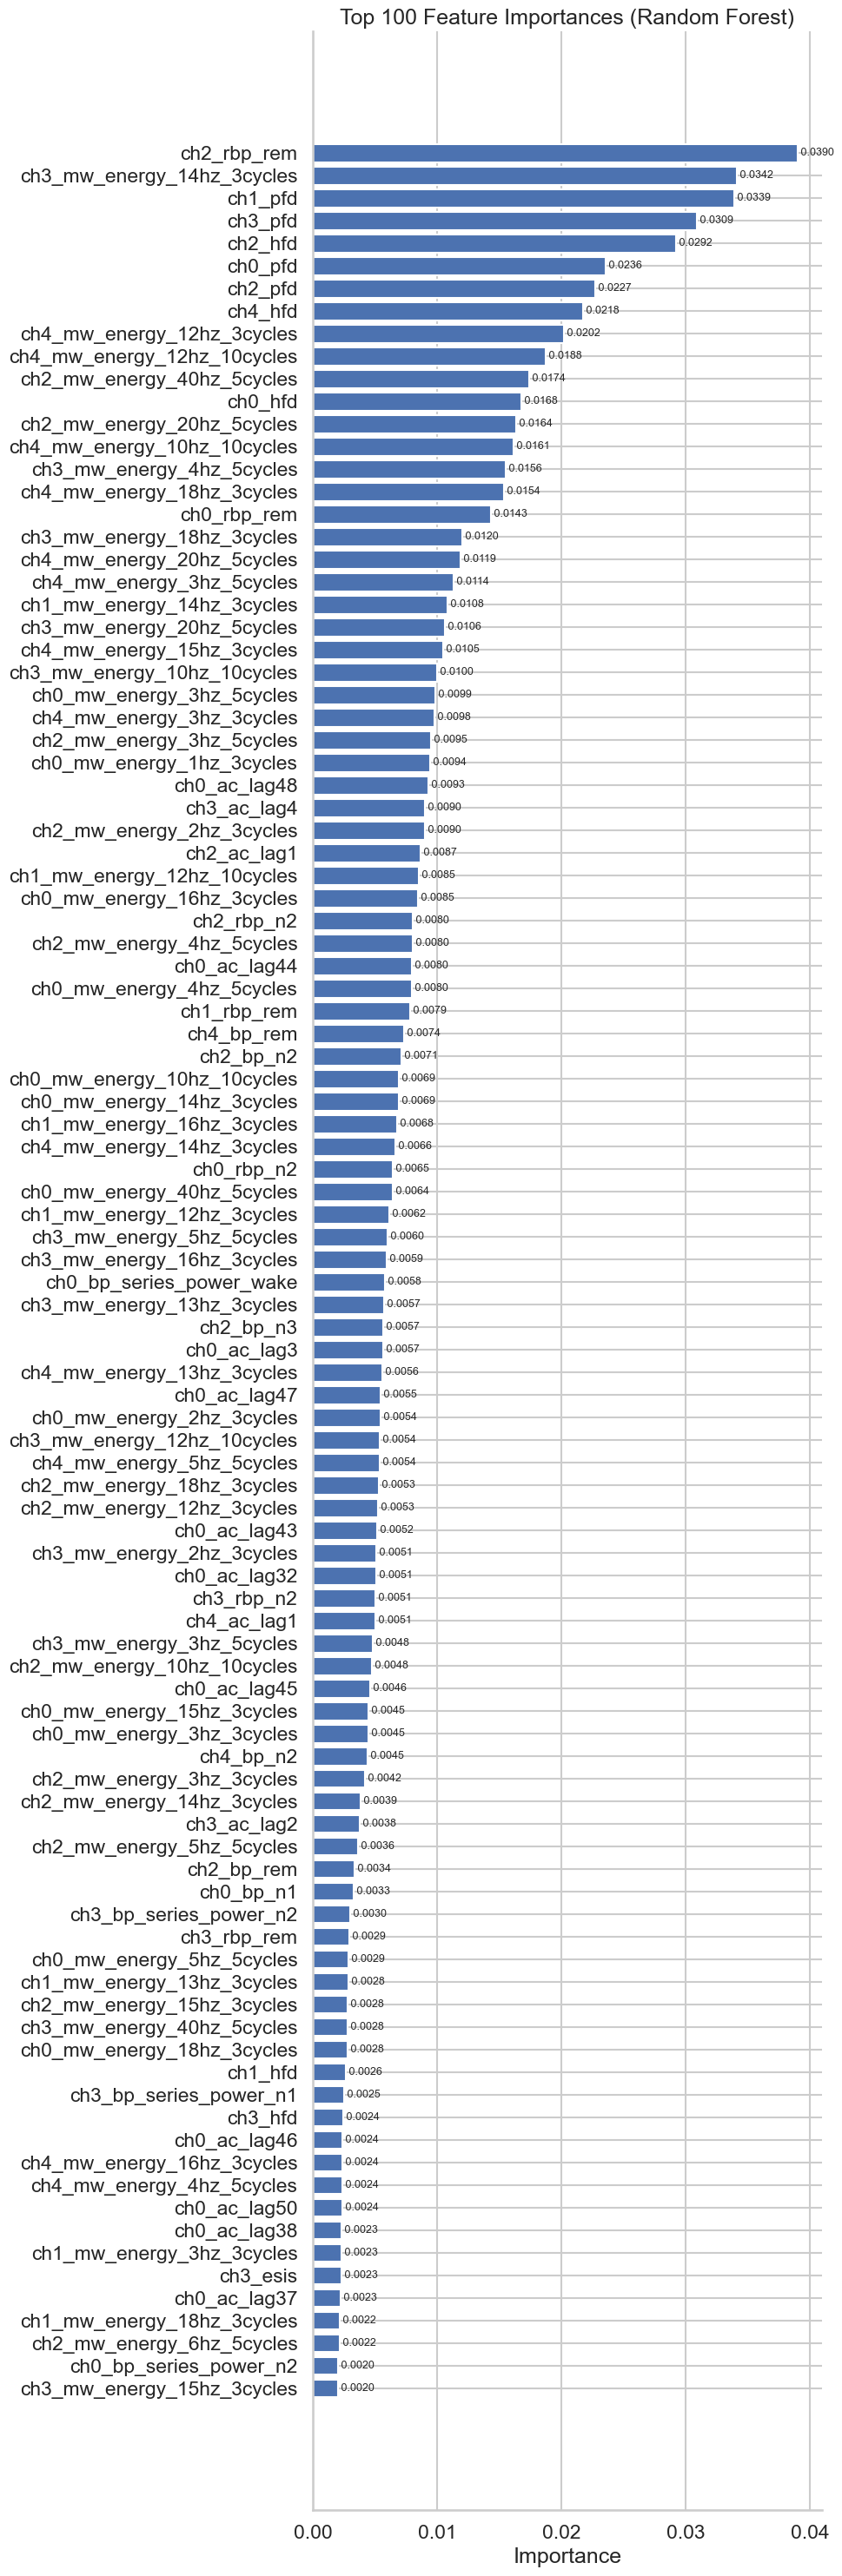

In [286]:
fig, top_indices, top_importances = plot_feature_importance(model, X_df.columns.tolist(), top_n=100)
plt.show()

In [302]:
kept_features = np.where(model.feature_importances_ > 0.001)[0]
len(kept_features)

139

In [183]:
importance_df = get_feature_importance_df(model, X_df.columns.tolist())
type_importance = analyze_feature_by_type(importance_df)
print(type_importance)

# fig, ax = plt.subplots(figsize=(12, 6))
# ax.barh(type_importance['type'], type_importance['sum'], color='#f7a399')
# ax.set_xlabel('Total Importance')
# ax.set_title('Feature Importance by Type (Amplitude, Frequency, Fractal Dim, etc.)')
# plt.tight_layout()

                  type       sum      mean  count
82                 pfd  0.128034  0.025607      5
75                 hfd  0.104820  0.020964      5
87             rbp_rem  0.102815  0.020563      5
61               bp_n2  0.063368  0.012674      5
65  bp_series_power_n2  0.035548  0.007110      5
..                 ...       ...       ...    ...
71           corr_prev  0.000797  0.000159      5
70           corr_next  0.000698  0.000140      5
78                mean  0.000670  0.000134      5
81         n3_amp_gt75  0.000150  0.000030      5
58     bp_corr_wake_n3  0.000000  0.000000      5

[91 rows x 4 columns]


           type       sum      mean  count
19          pfd  0.156959  0.031392      5
12          hfd  0.131673  0.026335      5
24      rbp_rem  0.104071  0.020814      5
1         bp_n2  0.092139  0.018428      5
21       rbp_n1  0.047600  0.009520      5
7          esis  0.045029  0.009006      5
22       rbp_n2  0.044434  0.008887      5
0         bp_n1  0.037372  0.007474      5
23       rbp_n3  0.031602  0.006320      5
25     rbp_wake  0.030210  0.006042      5
3        bp_rem  0.028610  0.005722      5
4       bp_wake  0.028412  0.005682      5
2         bp_n3  0.026678  0.005336      5
13          kfd  0.024361  0.004872      5
17          mmd  0.023399  0.004680      5
26          std  0.021214  0.004243      5
20          ptp  0.018875  0.003775      5
16          min  0.018003  0.003601      5
9          fdom  0.017984  0.003597      5
8     fcentroid  0.017418  0.003484      5
14          max  0.017376  0.003475      5
6     corr_prev  0.012233  0.002447      5
5     corr_

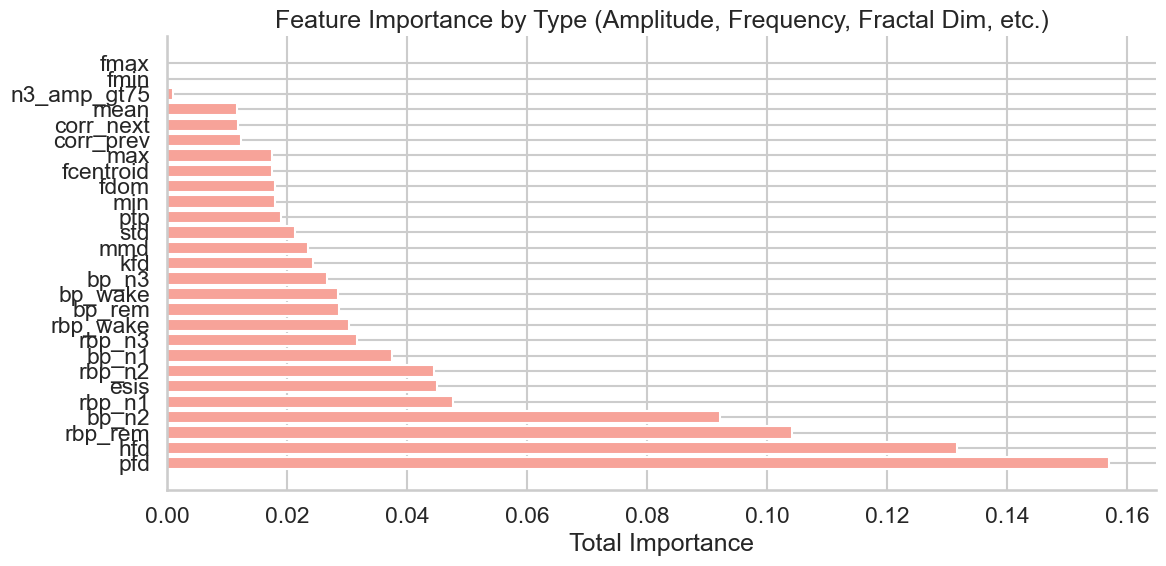

In [39]:
type_importance = analyze_feature_by_type(importance_df)
print(type_importance)

# fig, ax = plt.subplots(figsize=(12, 6))
# ax.barh(type_importance['type'], type_importance['sum'], color='#f7a399')
# ax.set_xlabel('Total Importance')
# ax.set_title('Feature Importance by Type (Amplitude, Frequency, Fractal Dim, etc.)')
# plt.tight_layout()

## Step 11 — Build the Submission DataFrame

Competition submissions require an `identifier` column combining record ID and epoch index. We mirror the CLI logic to ensure IDs match the provided template.


In [194]:
test_feature_frames = []
test_meta_frames = []

for record_id, signal_array in iter_signals_only(BUNDLE_DIR, 'test'):
    frame = extract_epoch_stats3(signal_array)
    frame['record_id'] = record_id
    test_feature_frames.append(frame[X_df.columns])
    test_meta_frames.append(frame[['record_id', 'epoch_index']])

test_X_df = pd.concat(test_feature_frames, ignore_index=True)
test_meta = pd.concat(test_meta_frames, ignore_index=True)

test_X = scaler.transform(test_X_df)
predictions = model.predict(test_X)

identifiers = (
    test_meta['record_id'].to_numpy(dtype=np.int64) * 10000
    + test_meta['epoch_index'].to_numpy(dtype=np.int64)
)
submission = pd.DataFrame({'identifier': identifiers, 'target': predictions})

sample_path = BUNDLE_DIR / 'sample.csv'
if sample_path.exists():
    sample = pd.read_csv(sample_path)
    submission = sample.drop(columns=['target']).merge(submission, on='identifier', how='left')
    missing = submission['target'].isna().sum()
    if missing:
        raise ValueError(f'Missing predictions for {missing} identifiers compared to sample template.')

submission.head()

C:\Users\agath\AppData\Local\Temp\ipykernel_19164\2436370223.py:38: RuntimeWarning: invalid value encountered in scalar divide
  centroid = float(np.sum(freqs * psd) / np.sum(psd))


,identifier,target
0,80000,0
1,80001,2
2,80002,3
3,80003,2
4,80004,2


## Step 12 — Save the Model, Summary, and Submission

Persist everything so that you can reuse the trained model or upload the CSV without rerunning the notebook.


In [195]:
submission.to_csv("submission2.csv", index=False)